# Neural System Identification Training and Prediction Example

This notebook shows the core workflow for one training run and one prediction plot workflow on the IEEE 9-bus dataset using the `wolf_2026_augmented` configuration set.


In [1]:
from copy import deepcopy
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
if not (ROOT / "neuralsysid").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from configurations.utils import resolve_config_references
from neuralsysid.data import io, noise, preparation, preprocessing
from neuralsysid.training import pipeline
from neuralsysid.utils import plotting

## Configuration

The first block controls training. The second block controls the prediction horizon and which rollout window is plotted.


In [2]:
DATA_DIR = ROOT / "data"

DATA_NAME = "ieee9_kron_"
CONFIG_SET = "wolf_2026_augmented"
MODEL_TYPE = "rk4_ieee9_restcn_noangle"
CHIP_TYPE = "cpu"
NORMALIZE_DATA = True
ADD_NOISE = True
SNR_DB = 30

EVAL_DATA_NAME = DATA_NAME
EVAL_SPLIT = "test"
EVAL_PREDICTION_SEQ_LEN = 500
EVAL_CUTOFF_SAMPLES = 500 - 64
EVAL_SAMPLE_INDEX = 0
EVAL_PLOT_GROUP_SIZE = 6
EVAL_PLOT_X_LIMITS = (0, 500)
EVAL_PLOT_CHANNEL_SLICE = slice(None)

## Train one model

This loads the train/dev/test split and the evaluation split up front, keeps clean and noisy copies, trains the model, and prepares the runtime config and training normalization statistics needed for later prediction plots.


In [3]:
config_module = importlib.import_module(f"configurations.{CONFIG_SET}.base")
model_config = deepcopy(config_module.BASE_CONFIGS[MODEL_TYPE])
model_config["meta"]["config_id"] = f"{CONFIG_SET}:{MODEL_TYPE}:{DATA_NAME}"

train_data_sets_clean, metadata = io.load_data(str(DATA_DIR / DATA_NAME))
train_data_sets = deepcopy(train_data_sets_clean)
if ADD_NOISE:
    noise.add_noise_snr(train_data_sets, snr_db=SNR_DB)
    model_config["meta"]["noise_db"] = SNR_DB

eval_data_sets_clean, _ = io.load_data(
    str(DATA_DIR / EVAL_DATA_NAME), extensions=[EVAL_SPLIT]
)
eval_data_sets_noisy = deepcopy(eval_data_sets_clean)
if ADD_NOISE:
    noise.add_noise_snr(eval_data_sets_noisy, snr_db=SNR_DB)

model, test_loss, data_stats_train = pipeline.learn_dynamics(
    model_config=model_config,
    hyperparameters=[],
    chip_type=CHIP_TYPE,
    data_sets=train_data_sets,
    normalize_data=NORMALIZE_DATA,
)

runtime_config = resolve_config_references(model_config, train_data_sets[0][1])

print(f"Dataset: {DATA_NAME}")
print(f"Sample time: {io.infer_sample_time(train_data_sets[0][0]):.6f} s")
print(f"Test loss: {test_loss:.6f}")
print(f"Metadata keys: {sorted(metadata)}")

testing model: 


--------------------------------------------------
Epoch     Train Loss               Dev Loss                 
--------------------------------------------------
0         0.107130229473114        0.091798132817660        
1         0.089138006525380        0.089704335800239        
2         0.069767697049039        0.063268379973514        
3         0.064220766403845        0.074848039874009        
4         0.050281318702868        0.048414071755750        
5         0.043191240834338        0.041779008827039        
6         0.035541877150536        0.039828785828182        
7         0.035537558474711        0.033715786944543        
8         0.030689927882382        0.032425977023585        
9         0.031686410307884        0.031168045209987        
10        0.027599797184978        0.031934807077050        
11        0.029537995745029        0.032328294590116        
12        0.026480753240841        0.027187116444111        
13        0.02910302765667

## Prepare one evaluation split

This can be the same dataset as above or another local dataset with the same structure. For evaluation, the notebook keeps one clean split as ground truth and one noisy copy as model input. Both are resampled to the model step size and then windowed with a new sequence length for plotting.


In [4]:
t_eval_raw, data_eval_raw = eval_data_sets_noisy[0]
t_eval_raw_groundtruth, data_eval_raw_groundtruth = eval_data_sets_clean[0]

t_eval, data_eval = preprocessing.resample_data_sets(
    [[t_eval_raw, deepcopy(data_eval_raw)]],
    t_sample=io.infer_sample_time(t_eval_raw),
    t_step=runtime_config["data"]["t_step"],
)[0]
_, data_eval_groundtruth = preprocessing.resample_data_sets(
    [[t_eval_raw_groundtruth, deepcopy(data_eval_raw_groundtruth)]],
    t_sample=io.infer_sample_time(t_eval_raw_groundtruth),
    t_step=runtime_config["data"]["t_step"],
)[0]

if NORMALIZE_DATA:
    data_eval_normalized, _ = preprocessing.normalize_data(
        deepcopy(data_eval), data_stats_train
    )
else:
    data_eval_normalized = deepcopy(data_eval)

print(f"Evaluation dataset: {EVAL_DATA_NAME}")
print(f"Evaluation split: {EVAL_SPLIT}")
print(f"Resampled length: {t_eval.shape[1]}")
print(f"Historic sequence length: {runtime_config['data']['hist_seq_len']}")
print(f"Prediction sequence length: {EVAL_PREDICTION_SEQ_LEN}")

Evaluation dataset: ieee9_kron_
Evaluation split: test
Resampled length: 25000
Historic sequence length: 64
Prediction sequence length: 500


## Predict one rollout dataset

This creates a new set of rollout windows with the chosen prediction horizon and then runs the model on all of them. `EVAL_SAMPLE_INDEX` selects which one you want to inspect.


In [5]:
model.set_n_steps(EVAL_PREDICTION_SEQ_LEN - 1)

plottable_sets = preparation.build_sequence_dataloaders(
    [t_eval],
    [data_eval_normalized],
    runtime_config["data"]["outputs"],
    runtime_config["data"]["controls"],
    batch_size=100000,
    shuffle=False,
    seq_len=EVAL_PREDICTION_SEQ_LEN,
    historic_seq_len=runtime_config["data"]["hist_seq_len"],
    cutoff_samples=EVAL_CUTOFF_SAMPLES,
)

plottable_sets_groundtruth = preparation.build_sequence_dataloaders(
    [t_eval],
    [deepcopy(data_eval_groundtruth)],
    runtime_config["data"]["outputs"],
    runtime_config["data"]["controls"],
    batch_size=100000,
    shuffle=False,
    seq_len=EVAL_PREDICTION_SEQ_LEN,
    historic_seq_len=runtime_config["data"]["hist_seq_len"],
    cutoff_samples=EVAL_CUTOFF_SAMPLES,
)

t_data_eval, _, evaluated_dataloader = plottable_sets[0]
_, _, evaluated_dataloader_groundtruth = plottable_sets_groundtruth[0]

in_feat, out_feat = list(evaluated_dataloader)[0]
y_hist, u_hist = in_feat[0]
u = in_feat[1]

with torch.no_grad():
    pred_traj = (
        model(y_hist, u_hist, u)[..., : len(runtime_config["data"]["outputs"])]
        .detach()
        .cpu()
        .numpy()
    )

meas_traj = out_feat.detach().cpu().numpy()
input_traj = u.detach().cpu().numpy()
true_traj = list(evaluated_dataloader_groundtruth)[0][1].detach().cpu().numpy()

if NORMALIZE_DATA:
    pred_traj = preprocessing.unnormalize(
        pred_traj,
        data_stats_train["mean_y"][runtime_config["data"]["outputs"]],
        data_stats_train["std_y"][runtime_config["data"]["outputs"]],
    )
    meas_traj = preprocessing.unnormalize(
        meas_traj,
        data_stats_train["mean_y"][runtime_config["data"]["outputs"]],
        data_stats_train["std_y"][runtime_config["data"]["outputs"]],
    )
    input_traj = preprocessing.unnormalize(
        input_traj,
        data_stats_train["mean_u"][runtime_config["data"]["controls"]],
        data_stats_train["std_u"][runtime_config["data"]["controls"]],
    )

print(f"Prediction tensor shape: {pred_traj.shape}")
print(f"Plotting sample: {EVAL_SAMPLE_INDEX}")

Prediction tensor shape: (49, 500, 6)
Plotting sample: 0


## Plot the selected rollout

Use `EVAL_PLOT_CHANNEL_SLICE` to restrict the shown output channels, for example `slice(0, 3)`.


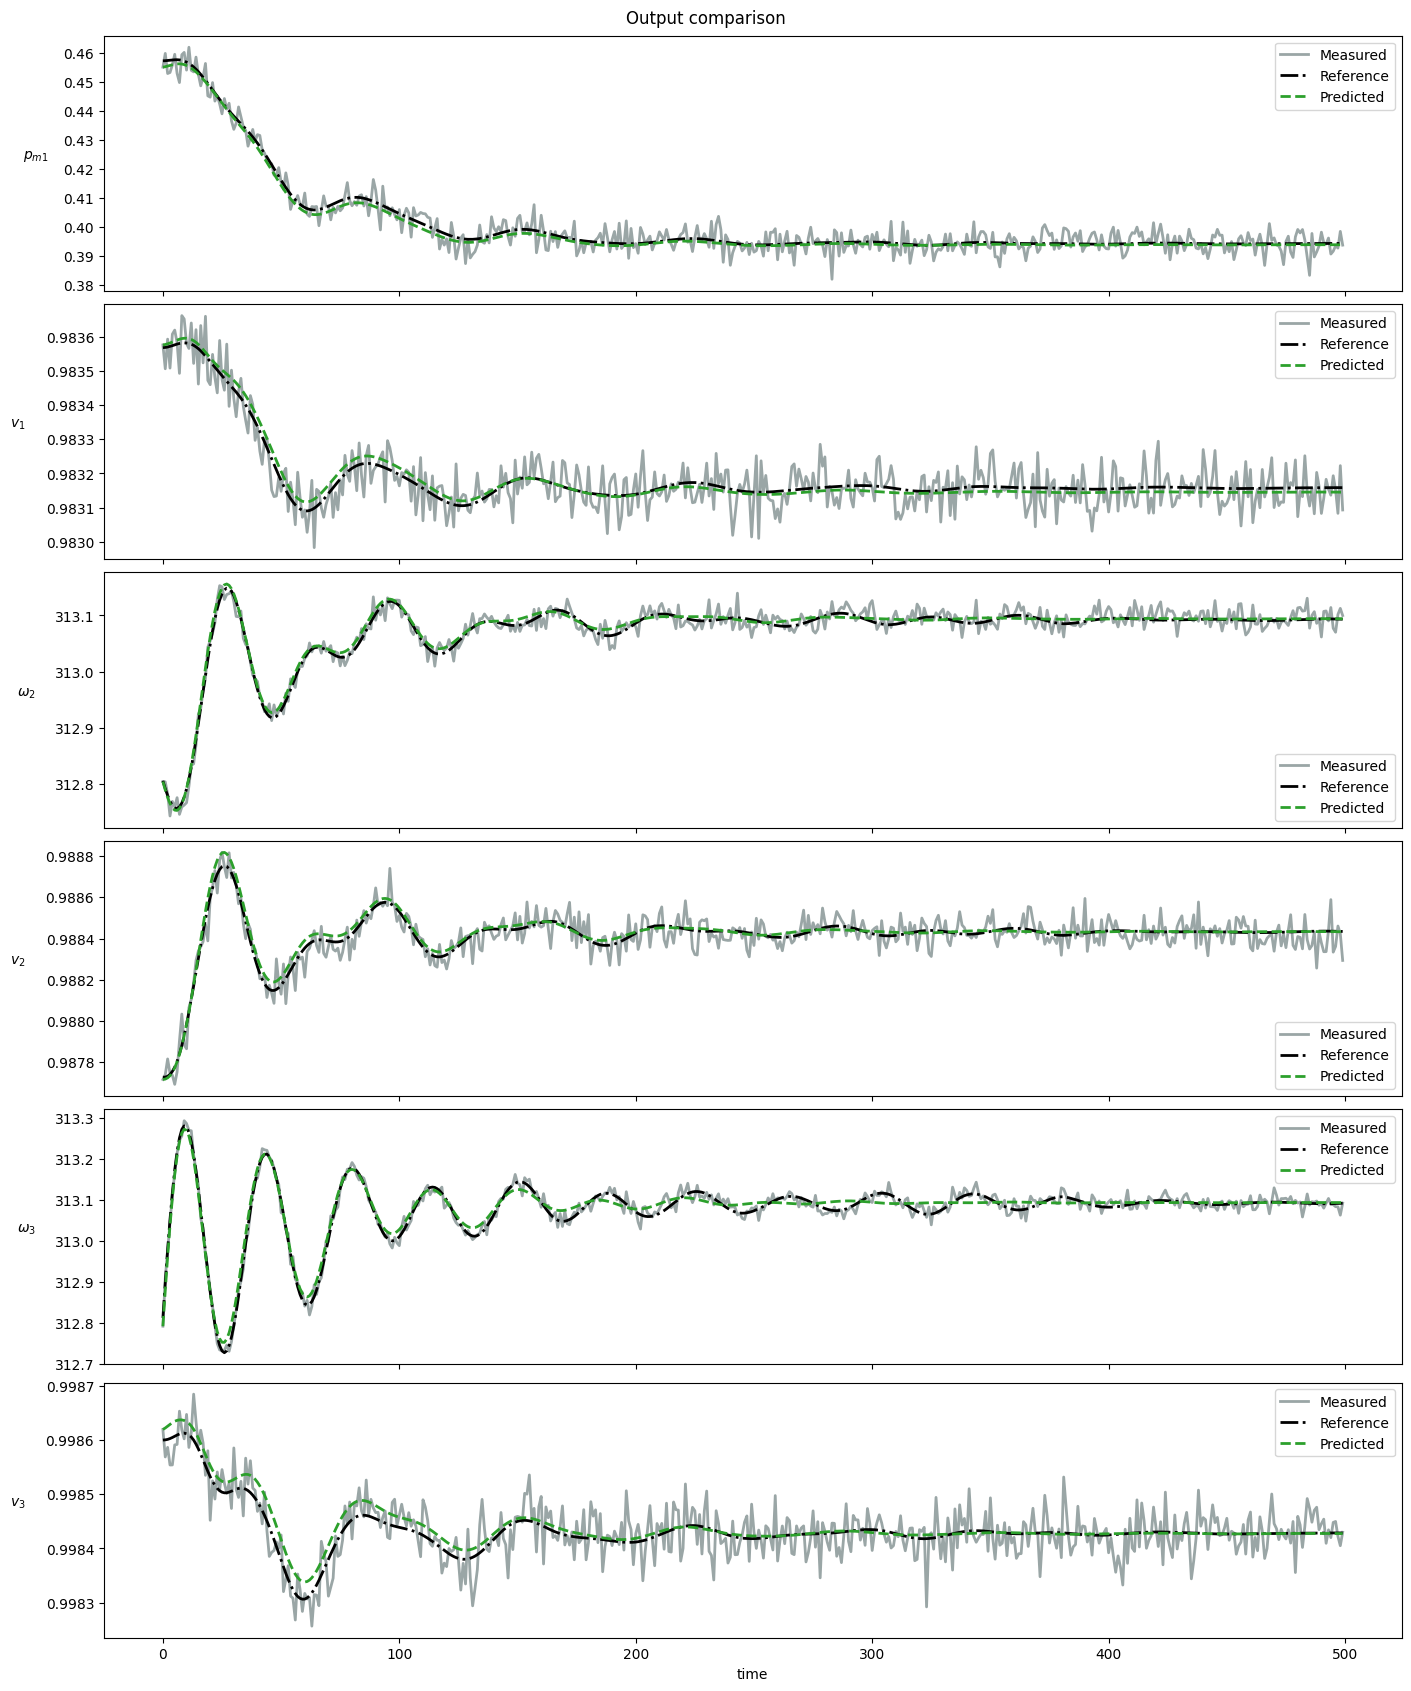

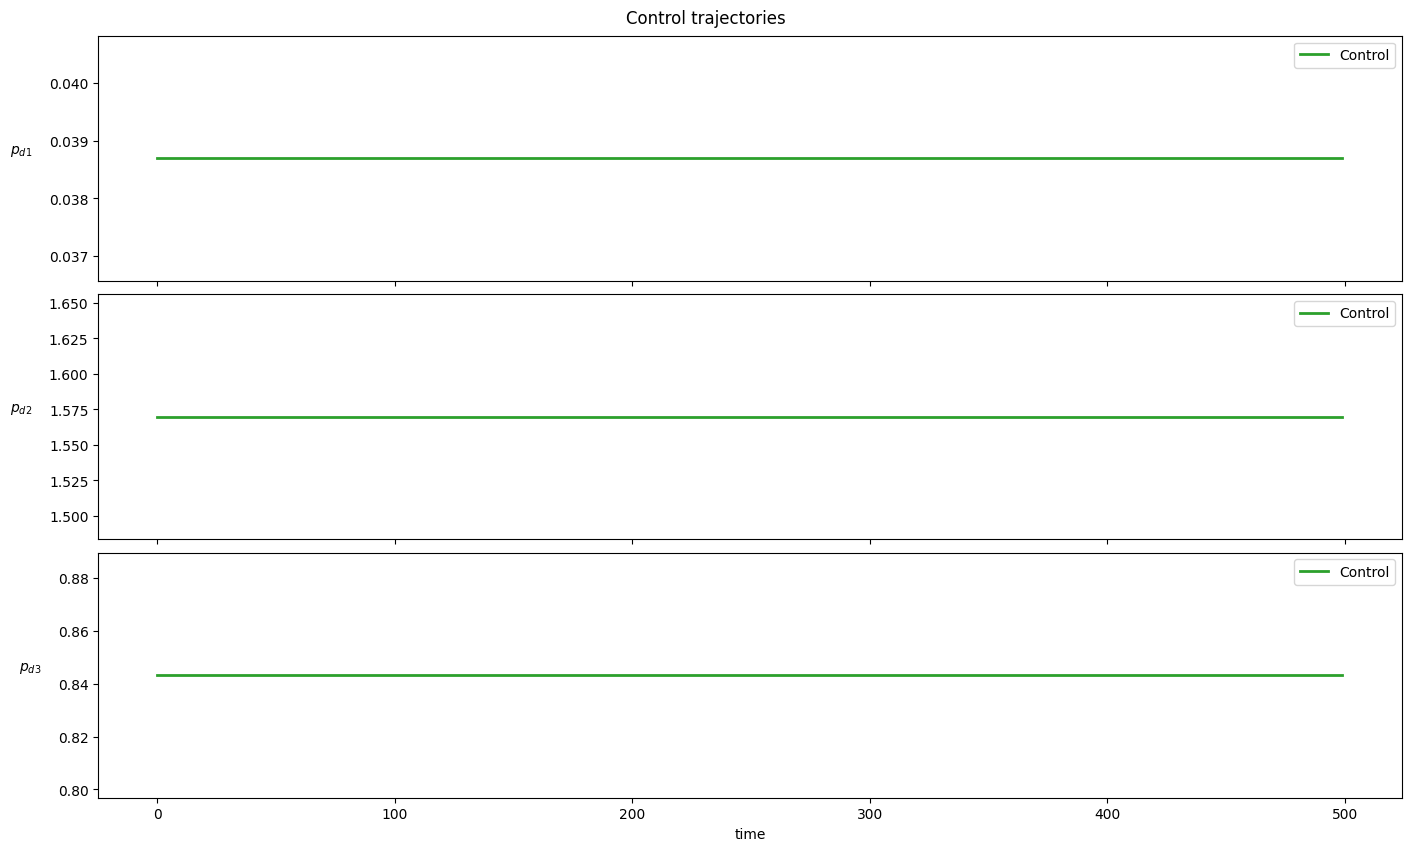

In [6]:
output_names = [
    data_eval_raw["output_names"][i] for i in runtime_config["data"]["outputs"]
]
control_names = [
    data_eval_raw["control_names"][i]
    for i in runtime_config["data"]["controls"]
]

selected_channels = list(range(len(output_names)))[EVAL_PLOT_CHANNEL_SLICE]

for start in range(0, len(selected_channels), EVAL_PLOT_GROUP_SIZE):
    stop = start + EVAL_PLOT_GROUP_SIZE
    channel_group = selected_channels[start:stop]
    plotting.plot_prediction_comparison(
        measured=meas_traj[EVAL_SAMPLE_INDEX][:, channel_group],
        reference=true_traj[EVAL_SAMPLE_INDEX][:, channel_group],
        predicted=pred_traj[EVAL_SAMPLE_INDEX][:, channel_group],
        controls=input_traj[EVAL_SAMPLE_INDEX] if start == 0 else None,
        output_names=[output_names[i] for i in channel_group],
        control_names=control_names,
        x_limits=EVAL_PLOT_X_LIMITS,
    )
    plt.show()